## 1. Persiapan Library

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

## 2. Mengunduh Dataset dari KaggleHub

In [3]:
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download("farzadnekouei/trash-type-image-dataset")
print("Lokasi dataset:", dataset_path)

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lokasi dataset: C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1


In [5]:
for root_dir, sub_dirs, file_list in os.walk(dataset_path):
    print(root_dir, "->", sub_dirs)

C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1 -> ['TrashType_Image_Dataset']
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset -> ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\cardboard -> []
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\glass -> []
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\metal -> []
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\paper -> []
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-image-dataset\versions\1\TrashType_Image_Dataset\plastic -> []
C:\Users\ASUS\.cache\kagglehub\datasets\farzadnekouei\trash-type-

## 3. Konfigurasi Parameter Dataset

In [6]:
DATA_DIR = dataset_path
IMAGE_DIM = (128, 128)
BATCH = 32
RANDOM_SEED = 42

## 4. Membuat Dataset Training dan Validasi

In [7]:
ds_train = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_DIM,
    batch_size=BATCH
)

ds_val = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_DIM,
    batch_size=BATCH
)

label_names = ds_train.class_names
print("Daftar kelas:", label_names)

Found 2527 files belonging to 1 classes.
Using 2022 files for training.
Found 2527 files belonging to 1 classes.
Using 505 files for validation.
Daftar kelas: ['TrashType_Image_Dataset']


## 5. Menampilkan Contoh Gambar dari Dataset

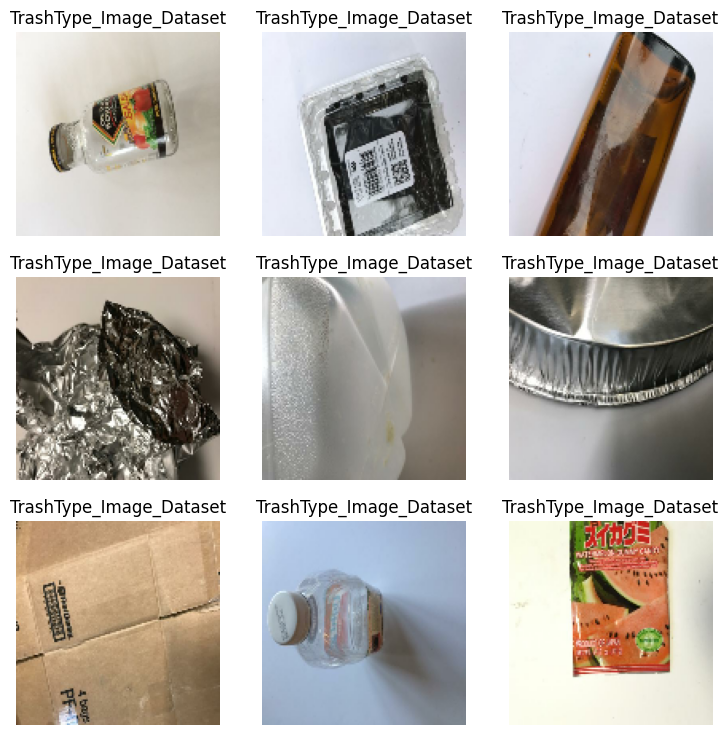

In [8]:
plt.figure(figsize=(9, 9))
for batch_images, batch_labels in ds_train.take(1):
    for idx in range(9):
        plt.subplot(3, 3, idx + 1)
        plt.imshow(batch_images[idx].numpy().astype("uint8"))
        plt.title(label_names[batch_labels[idx]])
        plt.axis("off")
plt.show()

## 6. Optimasi Pipeline Data

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
ds_train = ds_train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
ds_val = ds_val.cache().prefetch(buffer_size=AUTOTUNE)

total_classes = len(label_names)
print("Total kelas:", total_classes)

Total kelas: 1


## 7. Membangun Arsitektur Model CNN

In [10]:
cnn_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMAGE_DIM[0], IMAGE_DIM[1], 3)),

    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(total_classes, activation='softmax')
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()
print("Total parameter model:", cnn_model.count_params())

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,441 (8.09 MB)

 Trainable params: 2,121,217 (8.09 MB)

 Non-trainable params: 224 (896.00 B)

Total parameter model: 2121441


## 8. Melatih Model

In [11]:
TOTAL_EPOCH = 20

training_history = cnn_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=TOTAL_EPOCH
)

Epoch 1/20


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Ep

## 9. Visualisasi Hasil Training

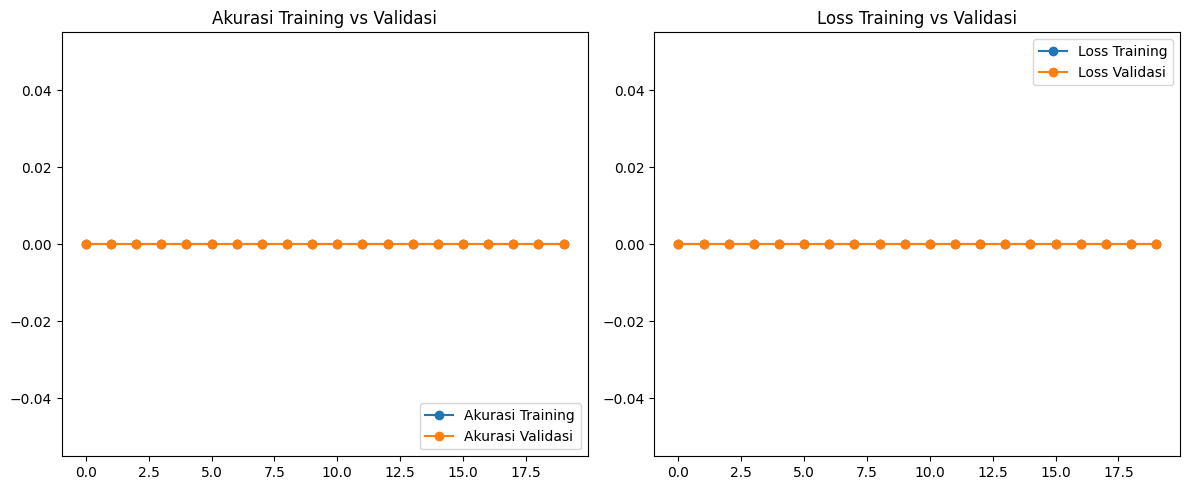

In [12]:
train_acc = training_history.history['accuracy']
valid_acc = training_history.history['val_accuracy']
train_loss = training_history.history['loss']
valid_loss = training_history.history['val_loss']
epoch_axis = range(TOTAL_EPOCH)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_axis, train_acc, label='Akurasi Training', marker='o')
plt.plot(epoch_axis, valid_acc, label='Akurasi Validasi', marker='o')
plt.legend(loc='lower right')
plt.title('Akurasi Training vs Validasi')

plt.subplot(1, 2, 2)
plt.plot(epoch_axis, train_loss, label='Loss Training', marker='o')
plt.plot(epoch_axis, valid_loss, label='Loss Validasi', marker='o')
plt.legend(loc='upper right')
plt.title('Loss Training vs Validasi')

plt.tight_layout()
plt.show()

## 10. Evaluasi Model pada Data Validasi

In [13]:
eval_loss, eval_acc = cnn_model.evaluate(ds_val)
print(f"Loss Validasi : {eval_loss:.4f}")
print(f"Akurasi Validasi : {eval_acc * 100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Loss Validasi : 0.0000
Akurasi Validasi : 0.00%


## 11. Classification Report dan Confusion Matrix

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


                         precision    recall  f1-score   support

TrashType_Image_Dataset       1.00      1.00      1.00       505

               accuracy                           1.00       505
              macro avg       1.00      1.00      1.00       505
           weighted avg       1.00      1.00      1.00       505



c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


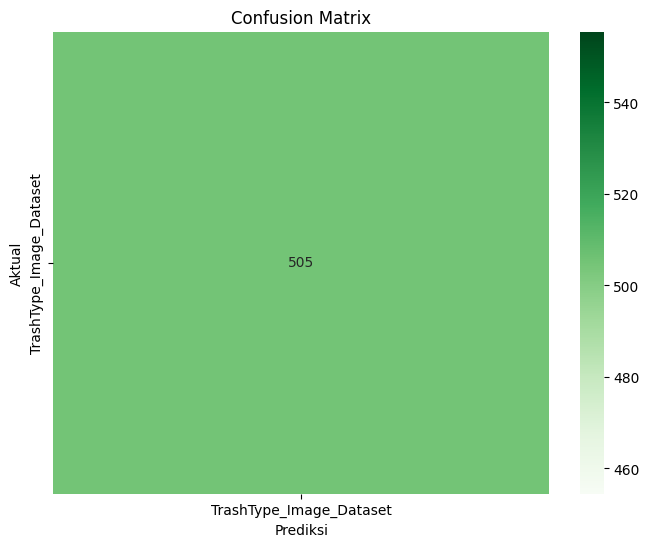

In [14]:
actual_labels = []
predicted_labels = []

for batch_images, batch_labels in ds_val:
    batch_preds = cnn_model.predict(batch_images, verbose=0)
    predicted_labels.extend(np.argmax(batch_preds, axis=1))
    actual_labels.extend(batch_labels.numpy())

print(classification_report(actual_labels, predicted_labels, target_names=label_names))

conf_mat = confusion_matrix(actual_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

## 12. Contoh Prediksi pada Gambar Validasi

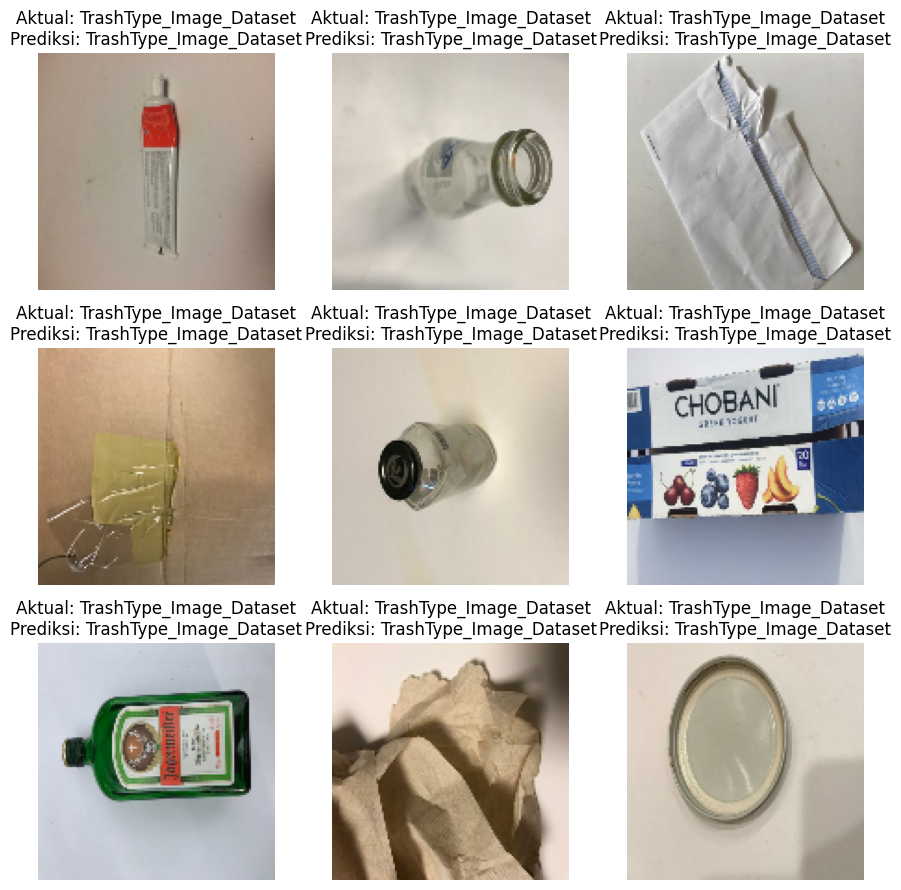

In [15]:
plt.figure(figsize=(9, 9))
for batch_images, batch_labels in ds_val.take(1):
    batch_preds = cnn_model.predict(batch_images, verbose=0)
    pred_idx = np.argmax(batch_preds, axis=1)
    for idx in range(9):
        plt.subplot(3, 3, idx + 1)
        plt.imshow(batch_images[idx].numpy().astype("uint8"))
        plt.title(f"Aktual: {label_names[batch_labels[idx]]}\nPrediksi: {label_names[pred_idx[idx]]}")
        plt.axis("off")
plt.tight_layout()
plt.show()

## 13. Menyimpan Model

In [16]:
cnn_model.save("model_klasifikasi_sampah.keras")
print("Model berhasil disimpan.")

Model berhasil disimpan.
